# Verificación del Dataset Final

Verificación de integridad y análisis de valores nulos.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette('husl')
%matplotlib inline

In [100]:
df = pd.read_csv('data/processed/dataset_final_mensual.csv')

print("="*80)
print("INFORMACIÓN BÁSICA")
print("="*80)
print(f"\nDimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumnas:\n{list(df.columns)}")

INFORMACIÓN BÁSICA

Dimensiones: 1,926,432 filas × 15 columnas
Memoria: 711.23 MB

Columnas:
['provincia_nombre', 'departamento_nombre', 'departamento_id', 'cultivo', 'año', 'mes', 'rendimiento', 'temperatura_celsius', 'precipitacion_mm', 'suelo_ind_prod', 'suelo_porc_sue1', 'suelo_profund_s1', 'suelo_alcalin_s1', 'produccion', 'sup_sembrada']


In [101]:
print("="*80)
print("TIPOS DE DATOS Y VALORES NULOS")
print("="*80)

info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})

print("\n", info_df)

total_nulos = df.isnull().sum().sum()
print(f"\nTotal de valores nulos: {total_nulos:,}")

if total_nulos > 0:
    print("\nColumnas con valores nulos:")
    nulos = df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
    for col, count in nulos.items():
        print(f"   {col}: {count:,} ({count/len(df)*100:.1f}%)")

TIPOS DE DATOS Y VALORES NULOS

                         Tipo   Nulos  % Nulos
provincia_nombre      object       0     0.00
departamento_nombre   object       0     0.00
departamento_id       object       0     0.00
cultivo               object       0     0.00
año                    int64       0     0.00
mes                    int64       0     0.00
rendimiento            int64       0     0.00
temperatura_celsius  float64  853584    44.31
precipitacion_mm     float64  853584    44.31
suelo_ind_prod       float64       0     0.00
suelo_porc_sue1      float64       0     0.00
suelo_profund_s1     float64       0     0.00
suelo_alcalin_s1      object       0     0.00
produccion             int64       0     0.00
sup_sembrada           int64       0     0.00

Total de valores nulos: 1,707,168

Columnas con valores nulos:
   temperatura_celsius: 853,584 (44.3%)
   precipitacion_mm: 853,584 (44.3%)


In [102]:
print("="*80)
print("DIMENSIONES GEOGRÁFICAS")
print("="*80)

print(f"\nProvincias únicas: {df['provincia_nombre'].nunique()}")
print(f"Departamentos únicos: {df['departamento_id'].nunique()}")
print(f"Cultivos únicos: {df['cultivo'].nunique()}")

print("\nTop 10 provincias:")
print(df['provincia_nombre'].value_counts().head(10))

print("\nTop 10 cultivos:")
print(df['cultivo'].value_counts().head(10))

DIMENSIONES GEOGRÁFICAS

Provincias únicas: 23
Departamentos únicos: 509
Cultivos únicos: 41

Top 10 provincias:
provincia_nombre
Buenos Aires           639804
Santa Fe               146016
Cordoba                140724
Chaco                  115272
Entre Rios             105876
La Pampa               103068
Corrientes              99888
Misiones                92460
Santiago Del Estero     91368
Salta                   79788
Name: count, dtype: int64

Top 10 cultivos:
cultivo
Maíz                212700
Trigo total         159504
Sorgo               145620
Soja total          143796
Avena               138408
Girasol             127764
Cebada forrajera     78864
Soja 1ra             77688
Centeno              72540
Papa total           67536
Name: count, dtype: int64


In [103]:
print("="*80)
print("DIMENSIÓN TEMPORAL")
print("="*80)

print(f"\nRango temporal: {df['año'].min()} - {df['año'].max()}")
print(f"Años únicos: {df['año'].nunique()}")
print(f"Meses únicos: {sorted(df['mes'].unique())}")

registros_por_año = df.groupby('año').size()
print(f"\nRegistros por año:")
print(f"   Promedio: {registros_por_año.mean():,.0f}")
print(f"   Mínimo: {registros_por_año.min():,} (año {registros_por_año.idxmin()})")
print(f"   Máximo: {registros_por_año.max():,} (año {registros_por_año.idxmax()})")

DIMENSIÓN TEMPORAL

Rango temporal: 1970 - 2025
Años únicos: 56
Meses únicos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Registros por año:
   Promedio: 34,401
   Mínimo: 20,196 (año 2000)
   Máximo: 50,556 (año 1980)


In [104]:
print("="*80)
print("VARIABLE OBJETIVO: RENDIMIENTO")
print("="*80)

print("\n", df['rendimiento'].describe())

print(f"\nRegistros con datos: {df['rendimiento'].notna().sum():,} ({df['rendimiento'].notna().sum()/len(df)*100:.1f}%)")
print(f"Registros sin datos: {df['rendimiento'].isna().sum():,}")

Q1 = df['rendimiento'].quantile(0.25)
Q3 = df['rendimiento'].quantile(0.75)
IQR = Q3 - Q1
outliers_alto = (df['rendimiento'] > (Q3 + 1.5 * IQR)).sum()

print(f"\nOutliers (método IQR): {outliers_alto:,} ({outliers_alto/len(df)*100:.2f}%)")

VARIABLE OBJETIVO: RENDIMIENTO

 count    1.926432e+06
mean     3.457251e+03
std      5.475230e+03
min      0.000000e+00
25%      1.000000e+03
50%      2.000000e+03
75%      3.500000e+03
max      3.000000e+05
Name: rendimiento, dtype: float64

Registros con datos: 1,926,432 (100.0%)
Registros sin datos: 0

Outliers (método IQR): 201,600 (10.46%)


In [105]:
print("="*80)
print("VARIABLES CLIMÁTICAS")
print("="*80)

print("\nTemperatura (°C):")
print(df['temperatura_celsius'].describe())
print(f"Registros con datos: {df['temperatura_celsius'].notna().sum():,} ({df['temperatura_celsius'].notna().sum()/len(df)*100:.1f}%)")

print("\nPrecipitación (mm):")
print(df['precipitacion_mm'].describe())
print(f"Registros con datos: {df['precipitacion_mm'].notna().sum():,} ({df['precipitacion_mm'].notna().sum()/len(df)*100:.1f}%)")

VARIABLES CLIMÁTICAS

Temperatura (°C):
count    1.072848e+06
mean     1.738682e+01
std      5.870898e+00
min     -1.486868e+01
25%      1.286685e+01
50%      1.773746e+01
75%      2.210904e+01
max      3.284927e+01
Name: temperatura_celsius, dtype: float64
Registros con datos: 1,072,848 (55.7%)

Precipitación (mm):
count    1.072848e+06
mean     2.929590e+00
std      2.424918e+00
min      0.000000e+00
25%      1.152039e+00
50%      2.349854e+00
75%      4.035950e+00
max      2.686501e+01
Name: precipitacion_mm, dtype: float64
Registros con datos: 1,072,848 (55.7%)


In [106]:
print("="*80)
print("VARIABLES DE SUELO")
print("="*80)

vars_suelo = [col for col in df.columns if col.startswith('suelo_')]

for var in vars_suelo:
    print(f"\n{var}:")
    
    if df[var].dtype in ['float64', 'int64']:
        stats = df[var].describe()
        print(f"   Media: {stats['mean']:.2f}")
        print(f"   Rango: [{stats['min']:.2f}, {stats['max']:.2f}]")
    else:
        print(f"   Tipo: Categórica")
        print(f"   Valores únicos: {df[var].nunique()}")
        print(f"   Distribución:")
        value_counts = df[var].value_counts().head(5)
        for val, count in value_counts.items():
            print(f"      - {val}: {count:,} ({count/len(df)*100:.1f}%)")

VARIABLES DE SUELO

suelo_ind_prod:
   Media: 29.37
   Rango: [9.13, 48.26]

suelo_porc_sue1:
   Media: 65.91
   Rango: [49.30, 87.00]

suelo_profund_s1:
   Media: 94.03
   Rango: [52.41, 389.51]

suelo_alcalin_s1:
   Tipo: Categórica
   Valores únicos: 4
   Distribución:
      - No sodico: 1,699,272 (88.2%)
      - No salino: 192,348 (10.0%)
      - Debil: 30,852 (1.6%)
      - -: 3,960 (0.2%)


In [107]:
print("="*80)
print("VERIFICACIÓN DE CONSISTENCIA")
print("="*80)

meses_por_grupo = df.groupby(['departamento_id', 'cultivo', 'año'])['mes'].nunique()
print(f"\nGranularidad mensual:")
print(f"   Grupos con 12 meses: {(meses_por_grupo == 12).sum():,} / {len(meses_por_grupo):,}")

duplicados = df.duplicated(subset=['departamento_id', 'cultivo', 'año', 'mes']).sum()
print(f"\nDuplicados: {duplicados}")

variacion_rendimiento = df.groupby(['departamento_id', 'cultivo', 'año'])['rendimiento'].std()
grupos_con_variacion = variacion_rendimiento[variacion_rendimiento > 0].dropna()
print(f"\nRendimiento consistente por año: {len(grupos_con_variacion) == 0}")

VERIFICACIÓN DE CONSISTENCIA



Granularidad mensual:
   Grupos con 12 meses: 160,536 / 160,536

Duplicados: 0

Rendimiento consistente por año: True


In [108]:
print("="*80)
print("MUESTRA DEL DATASET")
print("="*80)

print("\nPrimeras 20 filas:")
display(df.head(20))

print("\nMuestra aleatoria:")
display(df.sample(10, random_state=42))

MUESTRA DEL DATASET

Primeras 20 filas:


,provincia_nombre,departamento_nombre,departamento_id,cultivo,año,mes,rendimiento,temperatura_celsius,precipitacion_mm,suelo_ind_prod,suelo_porc_sue1,suelo_profund_s1,suelo_alcalin_s1,produccion,sup_sembrada
0,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,1,3333,22.368317,5.617142,34.550898,66.545659,77.879491,No sodico,10,3
1,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,2,3333,23.294342,1.991272,34.550898,66.545659,77.879491,No sodico,10,3
2,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,3,3333,19.947906,6.193161,34.550898,66.545659,77.879491,No sodico,10,3
3,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,4,3333,18.099762,3.725052,34.550898,66.545659,77.879491,No sodico,10,3
4,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,5,3333,12.083649,0.638962,34.550898,66.545659,77.879491,No sodico,10,3
5,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,6,3333,8.224274,0.946045,34.550898,66.545659,77.879491,No sodico,10,3
6,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,7,3333,8.897369,0.991821,34.550898,66.545659,77.879491,No sodico,10,3
7,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,8,3333,9.852448,0.617981,34.550898,66.545659,77.879491,No sodico,10,3
8,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,9,3333,14.838287,1.853943,34.550898,66.545659,77.879491,No sodico,10,3
9,Buenos Aires,25 DE MAYO,BUENOS AIRES - 25 DE MAYO,Ajo,1970,10,3333,14.759918,1.792908,34.550898,66.545659,77.879491,No sodico,10,3



Muestra aleatoria:


,provincia_nombre,departamento_nombre,departamento_id,cultivo,año,mes,rendimiento,temperatura_celsius,precipitacion_mm,suelo_ind_prod,suelo_porc_sue1,suelo_profund_s1,suelo_alcalin_s1,produccion,sup_sembrada
1791757,Buenos Aires,PEHUAJO,BUENOS AIRES - PEHUAJO,Trigo total,2013,2,2041,NaN,NaN,34.550898,66.545659,77.879491,No sodico,19800,14700
1084880,La Pampa,TRENEL,LA PAMPA - TRENEL,Maní,2013,9,2000,11.966461,1.531601,15.196154,87.000000,74.961538,No sodico,1400,700
567283,La Pampa,CALEU CALEU,LA PAMPA - CALEU CALEU,Centeno,1971,8,500,10.973297,2.735138,15.196154,87.000000,74.961538,No sodico,50,1000
615845,San Luis,GENERAL PEDERNERA,SAN LUIS - GENERAL PEDERNERA,Colza,2009,6,1100,9.896393,0.011444,20.061644,77.534247,64.041096,No sodico,77,70
576848,Mendoza,MALARGUE,MENDOZA - MALARGUE,Centeno,1970,9,0,NaN,NaN,15.428571,70.439560,74.175824,No sodico,0,20
1889163,Santa Fe,SAN MARTIN,SANTA FE - SAN MARTIN,Trigo total,1990,4,1493,NaN,NaN,35.365571,64.264990,126.928433,No sodico,112000,85000
1111188,Cordoba,TERCERO ARRIBA,CORDOBA - TERCERO ARRIBA,Mijo,2016,1,1800,NaN,NaN,34.600000,62.190083,82.157025,No sodico,180,100
580655,Salta,CHICOANA,SALTA - CHICOANA,Centeno,1974,12,0,19.099274,7.066727,34.696121,58.566810,76.939655,No sodico,0,110
1036916,Tucuman,RIO CHICO,TUCUMAN - RIO CHICO,Maíz,1986,9,3000,NaN,NaN,34.479798,52.575758,76.767677,No sodico,600,200
665126,Buenos Aires,PEHUAJO,BUENOS AIRES - PEHUAJO,Girasol,2000,3,1730,NaN,NaN,34.550898,66.545659,77.879491,No sodico,96700,56500


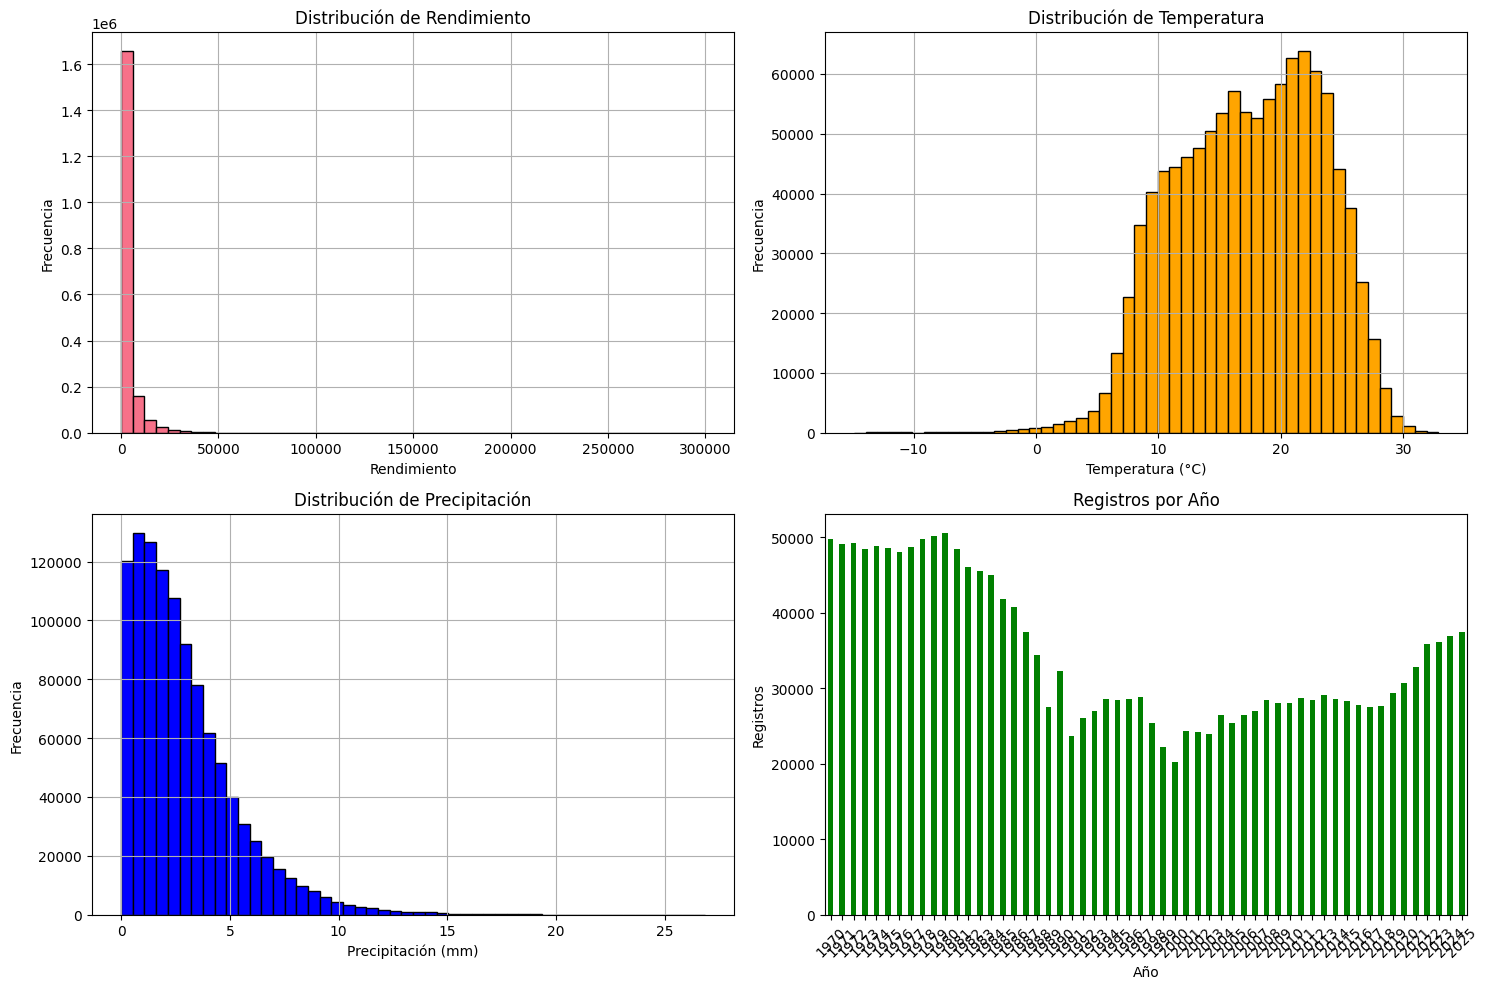

In [109]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df['rendimiento'].dropna().hist(bins=50, ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('Distribución de Rendimiento')
axes[0, 0].set_xlabel('Rendimiento')
axes[0, 0].set_ylabel('Frecuencia')

df['temperatura_celsius'].dropna().hist(bins=50, ax=axes[0, 1], edgecolor='black', color='orange')
axes[0, 1].set_title('Distribución de Temperatura')
axes[0, 1].set_xlabel('Temperatura (°C)')
axes[0, 1].set_ylabel('Frecuencia')

df['precipitacion_mm'].dropna().hist(bins=50, ax=axes[1, 0], edgecolor='black', color='blue')
axes[1, 0].set_title('Distribución de Precipitación')
axes[1, 0].set_xlabel('Precipitación (mm)')
axes[1, 0].set_ylabel('Frecuencia')

df.groupby('año').size().plot(kind='bar', ax=axes[1, 1], color='green')
axes[1, 1].set_title('Registros por Año')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Registros')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [110]:
print("="*80)
print("RESUMEN DE VERIFICACIÓN")
print("="*80)

checks = {
    'Dataset cargado': df.shape[0] > 0,
    'Columnas completas': len(df.columns) >= 15,
    'Granularidad mensual': df['mes'].nunique() == 12,
    'Sin duplicados': df.duplicated(subset=['departamento_id', 'cultivo', 'año', 'mes']).sum() == 0,
    'Variable objetivo': 'rendimiento' in df.columns,
    'Variables climáticas': 'temperatura_celsius' in df.columns and 'precipitacion_mm' in df.columns,
    'Variables de suelo': any(col.startswith('suelo_') for col in df.columns)
}

print("\nChecklist:")
for check, passed in checks.items():
    status = "[OK]" if passed else "[FAIL]"
    print(f"   {status} {check}")

print("="*80)

RESUMEN DE VERIFICACIÓN

Checklist:
   [OK] Dataset cargado
   [OK] Columnas completas
   [OK] Granularidad mensual
   [OK] Sin duplicados
   [OK] Variable objetivo
   [OK] Variables climáticas
   [OK] Variables de suelo


## Análisis de Valores Nulos en Datos Climáticos

Los datos climáticos presentan 51.4% de valores nulos. Las siguientes celdas analizan las causas.

In [111]:
print("="*80)
print("CAUSA 1: DEPARTAMENTOS SIN COBERTURA CLIMÁTICA")
print("="*80)

df_sin_clima = df[df['temperatura_celsius'].isna()].copy()
df_con_clima = df[df['temperatura_celsius'].notna()].copy()

deptos_cultivos = set(df['departamento_id'].unique())
deptos_con_clima = set(df_con_clima['departamento_id'].unique())
deptos_sin_clima = deptos_cultivos - deptos_con_clima

print(f"\nAnálisis geográfico:")
print(f"   Total departamentos: {len(deptos_cultivos)}")
print(f"   Con datos climáticos: {len(deptos_con_clima)}")
print(f"   Sin datos climáticos: {len(deptos_sin_clima)}")

registros_deptos_sin_clima = df[df['departamento_id'].isin(deptos_sin_clima)].shape[0]
porcentaje_deptos_sin_clima = (registros_deptos_sin_clima / len(df)) * 100

print(f"\nImpacto:")
print(f"   Registros sin clima: {registros_deptos_sin_clima:,} ({porcentaje_deptos_sin_clima:.1f}%)")

if len(deptos_sin_clima) > 0:
    print(f"\nEjemplos de departamentos sin cobertura (10 primeros):")
    for depto in sorted(list(deptos_sin_clima))[:10]:
        info = df[df['departamento_id'] == depto].iloc[0]
        registros = df[df['departamento_id'] == depto].shape[0]
        print(f"   {info['provincia_nombre']} - {info['departamento_nombre']} ({registros:,} registros)")

CAUSA 1: DEPARTAMENTOS SIN COBERTURA CLIMÁTICA

Análisis geográfico:
   Total departamentos: 509
   Con datos climáticos: 282
   Sin datos climáticos: 227

Impacto:
   Registros sin clima: 850,044 (44.1%)

Ejemplos de departamentos sin cobertura (10 primeros):
   Buenos Aires - BAHIA BLANCA (5,868 registros)
   Buenos Aires - BENITO JUAREZ (7,332 registros)
   Buenos Aires - BOLIVAR (6,480 registros)
   Buenos Aires - CANUELAS (5,520 registros)
   Buenos Aires - CAPITAN SARMIENTO (6,480 registros)
   Buenos Aires - CHASCOMUS (6,108 registros)
   Buenos Aires - COLON (6,336 registros)
   Buenos Aires - CORONEL DE MARINA L ROSALES (5,412 registros)
   Buenos Aires - CORONEL SUAREZ (7,968 registros)
   Buenos Aires - ESTEBAN ECHEVERRIA (1,416 registros)


In [112]:
print("="*80)
print("CAUSA 2: MESES FALTANTES EN ARCHIVOS NETCDF")
print("="*80)

df_deptos_con_cobertura = df[df['departamento_id'].isin(deptos_con_clima)].copy()

print(f"\nAnálisis en departamentos con cobertura:")
print(f"   Total registros: {len(df_deptos_con_cobertura):,}")

nulos_por_mes = df_deptos_con_cobertura.groupby('mes').agg({
    'temperatura_celsius': lambda x: x.isna().sum(),
    'departamento_id': 'count'
}).rename(columns={'temperatura_celsius': 'nulos', 'departamento_id': 'total'})

nulos_por_mes['% nulos'] = (nulos_por_mes['nulos'] / nulos_por_mes['total'] * 100).round(1)

print(f"\nNulos por mes:")
print(nulos_por_mes)

meses_problematicos = nulos_por_mes[nulos_por_mes['% nulos'] > 90].index.tolist()
if meses_problematicos:
    meses_nombres = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio',
                     7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}
    print(f"\nMeses con >90% nulos:")
    for mes in meses_problematicos:
        print(f"   Mes {mes} ({meses_nombres[mes]}): {nulos_por_mes.loc[mes, '% nulos']:.1f}%")

CAUSA 2: MESES FALTANTES EN ARCHIVOS NETCDF

Análisis en departamentos con cobertura:
   Total registros: 1,076,388

Nulos por mes:
     nulos  total  % nulos
mes                       
1        0  89699      0.0
2        0  89699      0.0
3        0  89699      0.0
4        0  89699      0.0
5        0  89699      0.0
6        0  89699      0.0
7        0  89699      0.0
8        0  89699      0.0
9        0  89699      0.0
10       0  89699      0.0
11    1770  89699      2.0
12    1770  89699      2.0


In [113]:
print("="*80)
print("EJEMPLOS DE OUTLIERS EXTREMOS")
print("="*80)

# Obtener los outliers más extremos
outliers_extremos = df[df['is_outlier_global'] == True].nlargest(20, 'rendimiento')

print("\nTop 20 rendimientos más altos (posibles outliers o cultivos especiales):")
print(outliers_extremos[['provincia_nombre', 'departamento_nombre', 'cultivo', 'año', 
                          'rendimiento', 'sup_sembrada', 'produccion']].to_string())

# Verificar si son errores o cultivos con alta productividad natural
print("\n\nDistribución de outliers extremos por cultivo:")
print(outliers_extremos['cultivo'].value_counts())

EJEMPLOS DE OUTLIERS EXTREMOS


KeyError: 'is_outlier_global'

In [ ]:
print("="*80)
print("DECISIÓN SOBRE OUTLIERS")
print("="*80)

print("\nAnálisis de diferentes estrategias:")

# Estrategia 1: Mantener todos
n_original = len(df)
print(f"\n1. MANTENER TODOS LOS DATOS:")
print(f"   - Registros: {n_original:,}")
print(f"   - Ventajas: Máxima información, respeta variabilidad natural de cultivos")
print(f"   - Desventajas: Outliers pueden afectar modelos lineales")

# Estrategia 2: Eliminar outliers globales
df_sin_outliers_global = df[df['is_outlier_global'] == False]
n_sin_global = len(df_sin_outliers_global)
print(f"\n2. ELIMINAR OUTLIERS GLOBALES (IQR global):")
print(f"   - Registros: {n_sin_global:,} (pérdida de {n_original - n_sin_global:,}, {(n_original - n_sin_global)/n_original*100:.1f}%)")
print(f"   - Ventajas: Distribución más normal")
print(f"   - Desventajas: Ignora que diferentes cultivos tienen rangos naturales distintos")

# Estrategia 3: Eliminar outliers por cultivo
def detect_outliers_by_crop(group):
    Q1 = group['rendimiento'].quantile(0.25)
    Q3 = group['rendimiento'].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    return ~((group['rendimiento'] < lower) | (group['rendimiento'] > upper))

df['is_outlier_by_crop'] = ~df.groupby('cultivo')['rendimiento'].transform(detect_outliers_by_crop)
df_sin_outliers_cultivo = df[df['is_outlier_by_crop'] == False]
n_sin_cultivo = len(df_sin_outliers_cultivo)
print(f"\n3. ELIMINAR OUTLIERS POR CULTIVO (IQR por cultivo):")
print(f"   - Registros: {n_sin_cultivo:,} (pérdida de {n_original - n_sin_cultivo:,}, {(n_original - n_sin_cultivo)/n_original*100:.1f}%)")
print(f"   - Ventajas: Respeta rangos naturales de cada cultivo")
print(f"   - Desventajas: Puede eliminar casos reales de alta productividad")

# Estrategia 4: Winsorización (cap en percentiles)
p99 = df['rendimiento'].quantile(0.99)
p01 = df['rendimiento'].quantile(0.01)
print(f"\n4. WINSORIZACIÓN (cap en p1 y p99):")
print(f"   - Límite inferior: {p01:.0f} kg/ha")
print(f"   - Límite superior: {p99:.0f} kg/ha")
print(f"   - Ventajas: No se pierden datos, solo se ajustan extremos")
print(f"   - Desventajas: Modifica distribución original")

print("\n" + "="*80)
print("RECOMENDACIÓN:")
print("="*80)
print("\nPara el modelado:")
print("   1. Comenzar con TODOS LOS DATOS (modelos de árbol son robustos)")
print("   2. Para modelos lineales, probar OUTLIERS POR CULTIVO")
print("   3. Siempre documentar la estrategia y comparar resultados")
print("   4. Considerar feature engineering: log-transform de rendimiento")
print("\nCultivos con valores extremos naturales (conservar):")
extremos_naturales = stats_cultivos.nlargest(5, 'max')[['count', 'mean', 'max']]
print(extremos_naturales.to_string())

In [ ]:
# Visualización de outliers
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Boxplot por cultivo (top 10)
top10_cultivos_nombres = df['cultivo'].value_counts().head(10).index
df_top10 = df[df['cultivo'].isin(top10_cultivos_nombres)]

axes[0, 0].boxplot([df_top10[df_top10['cultivo'] == c]['rendimiento'].dropna() 
                     for c in top10_cultivos_nombres],
                    labels=top10_cultivos_nombres, vert=True)
axes[0, 0].set_title('Boxplot de Rendimiento - Top 10 Cultivos', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Rendimiento (kg/ha)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Distribución con y sin outliers
axes[0, 1].hist(df['rendimiento'].dropna(), bins=50, alpha=0.7, 
                label='Con outliers', edgecolor='black', color='steelblue')
axes[0, 1].hist(df[df['is_outlier_global'] == False]['rendimiento'].dropna(), 
                bins=50, alpha=0.7, label='Sin outliers', edgecolor='black', color='orange')
axes[0, 1].set_xlabel('Rendimiento (kg/ha)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Rendimiento', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Porcentaje de outliers por cultivo
outliers_pct_by_crop = df.groupby('cultivo').apply(
    lambda x: (x['is_outlier_global'].sum() / len(x)) * 100, 
    include_groups=False
).sort_values(ascending=False).head(15)

axes[1, 0].barh(range(len(outliers_pct_by_crop)), outliers_pct_by_crop.values, 
                color='coral', edgecolor='black')
axes[1, 0].set_yticks(range(len(outliers_pct_by_crop)))
axes[1, 0].set_yticklabels(outliers_pct_by_crop.index, fontsize=9)
axes[1, 0].set_xlabel('% de Outliers')
axes[1, 0].set_title('Top 15 Cultivos con Mayor % de Outliers', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Outliers a lo largo del tiempo
outliers_por_año = df.groupby('año').agg({
    'is_outlier_global': 'sum',
    'rendimiento': 'count'
})
outliers_por_año['pct'] = (outliers_por_año['is_outlier_global'] / outliers_por_año['rendimiento']) * 100

axes[1, 1].plot(outliers_por_año.index, outliers_por_año['pct'], 
                marker='o', linewidth=2, color='darkred', markersize=4)
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('% de Outliers')
axes[1, 1].set_title('Evolución de Outliers en el Tiempo', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=10, color='gray', linestyle='--', alpha=0.5, label='Promedio global (10.78%)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
print("="*80)
print("EJEMPLOS DE OUTLIERS EXTREMOS")
print("="*80)

# Obtener los outliers más extremos
outliers_extremos = df[df['is_outlier_global'] == True].nlargest(20, 'rendimiento')

print("\nTop 20 rendimientos más altos (posibles outliers o cultivos especiales):")
print(outliers_extremos[['provincia_nombre', 'departamento_nombre', 'cultivo', 'año', 
                          'rendimiento', 'sup_sembrada', 'produccion']].to_string())

# Verificar si son errores o cultivos con alta productividad natural
print("\n\nDistribución de outliers extremos por cultivo:")
print(outliers_extremos['cultivo'].value_counts())

In [ ]:
print("="*80)
print("OUTLIERS POR CULTIVO")
print("="*80)

# Calcular estadísticas por cultivo
stats_cultivos = df.groupby('cultivo')['rendimiento'].agg([
    'count', 'mean', 'std', 'min', 'max',
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75))
])

stats_cultivos['IQR'] = stats_cultivos['Q3'] - stats_cultivos['Q1']
stats_cultivos['upper_bound'] = stats_cultivos['Q3'] + 1.5 * stats_cultivos['IQR']

# Contar outliers por cultivo
def count_outliers_by_crop(group):
    Q1 = group['rendimiento'].quantile(0.25)
    Q3 = group['rendimiento'].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    n_outliers = ((group['rendimiento'] < lower) | (group['rendimiento'] > upper)).sum()
    pct_outliers = (n_outliers / len(group)) * 100
    return pd.Series({'n_outliers': n_outliers, 'pct_outliers': pct_outliers})

outliers_by_crop = df.groupby('cultivo').apply(count_outliers_by_crop, include_groups=False)
stats_cultivos = stats_cultivos.join(outliers_by_crop)

# Ordenar por % de outliers y mostrar top 15
print("\nTop 15 cultivos con mayor % de outliers:")
top15_outliers = stats_cultivos.sort_values('pct_outliers', ascending=False).head(15)
print(top15_outliers[['count', 'mean', 'max', 'n_outliers', 'pct_outliers']].to_string())

print("\n\nCultivos principales (mayor cantidad de registros):")
top10_cultivos = stats_cultivos.sort_values('count', ascending=False).head(10)
print(top10_cultivos[['count', 'mean', 'max', 'n_outliers', 'pct_outliers']].to_string())

In [ ]:
print("="*80)
print("ANÁLISIS DE OUTLIERS EN RENDIMIENTO")
print("="*80)

# Calcular outliers globales usando IQR
Q1 = df['rendimiento'].quantile(0.25)
Q3 = df['rendimiento'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nMétodo IQR Global:")
print(f"   Q1: {Q1:,.0f} kg/ha")
print(f"   Q3: {Q3:,.0f} kg/ha")
print(f"   IQR: {IQR:,.0f} kg/ha")
print(f"   Límite inferior: {lower_bound:,.0f} kg/ha")
print(f"   Límite superior: {upper_bound:,.0f} kg/ha")

# Identificar outliers
df['is_outlier_global'] = (df['rendimiento'] < lower_bound) | (df['rendimiento'] > upper_bound)

outliers_bajos = (df['rendimiento'] < lower_bound).sum()
outliers_altos = (df['rendimiento'] > upper_bound).sum()
total_outliers = df['is_outlier_global'].sum()

print(f"\nOutliers detectados:")
print(f"   Bajos (<{lower_bound:,.0f}): {outliers_bajos:,} ({outliers_bajos/len(df)*100:.2f}%)")
print(f"   Altos (>{upper_bound:,.0f}): {outliers_altos:,} ({outliers_altos/len(df)*100:.2f}%)")
print(f"   Total: {total_outliers:,} ({total_outliers/len(df)*100:.2f}%)")

## Análisis Detallado de Outliers

Se identificaron 199,080 outliers (10.78%) en la variable `rendimiento`. A continuación se analiza su naturaleza y distribución por cultivo.